# SPY signature forecasting — train/test with fixed settings

**Question.** How does a model trained with fixed default settings perform compared with the configuration chosen in the original validation-based report?

This notebook performs **training and testing only**. The new model uses `ForecastConfig()` defaults declared before the test replay. No validation period, validation search or hyperparameter selection is executed here. For comparison, the original report's already selected configuration is read from `results/daily_refit/run_info.json` and replayed on the same data and dates. Its prior selection used 2023; that historical provenance is retained rather than presented as a model that was never validated.

Both models predict one next-session SPY log return and refit daily on at most 756 matured examples. Both use a 20-session lookback, the same 19 quantitative factors, and **310 test issue sessions from 2024-01-02 through 2025-03-27**, targeting closes 2024-01-03 through 2025-03-28. Exact dates are printed below.

**Interpretation.** This compares a fixed default configuration with a previously selected configuration. It cannot isolate a causal effect of removing validation. The original daily refit already includes matured 2023 labels in test-time training, so removing validation does not add those observations to its rolling training window. With identical settings and data, the two replay procedures produce identical forecasts.

The primary comparison metric is full-test return MAE. RMSE, direction accuracy, balanced accuracy, one full-period Pearson Corr per model, and shared-training normalized MSE are supporting metrics. These test dates have already been inspected in the original report, so this comparison is exploratory.

## 1. Settings fixed before the replay

The default no-validation model has response signature depth 3, compared with depth 2 in the current original report. All settings are displayed and saved. Edit `FIXED_CONFIG` for a prespecified future experiment; changing it after reviewing this test makes the test part of model tuning.

Train/test means a chronological walk-forward replay here. At issue close $t$, use only labels whose target closes have been observed, then forecast $r_{t+1}=\log(C_{t+1}/C_t)$. Test outcomes become usable in later daily refits after their own target closes.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT = Path.cwd()
if not (PROJECT / 'src' / 'spy_adaptive_lasso.py').exists():
    PROJECT = Path('Signature_Price_Forecast').resolve()
sys.path.insert(0, str(PROJECT / 'src'))
from spy_adaptive_lasso import (ForecastConfig, load_market_data, make_samples,
                                replay, score_predictions, reconstruct_price_comparison)
ROOT = PROJECT.parent
OUTPUT = PROJECT / 'results' / 'train_test_comparison'
OUTPUT.mkdir(parents=True, exist_ok=True)
REFERENCE = PROJECT / 'results' / 'daily_refit'
USE_FINMULTITIME = True
DATA_START, DATA_END = '2018-01-01', '2025-03-28'
TEST_START, TEST_END = '2024-01-01', '2025-03-27'
PLOT_AFTER_DATE = '2024-09-01'
DIRECTION_RETURN_THRESHOLD = 0.0
BLOCK_LENGTH, BOOTSTRAP_REPETITIONS, SEED = 20, 1000, 17

# Existing library defaults; no candidate grid or validation selection.
FIXED_CONFIG = ForecastConfig()
if not (REFERENCE / 'run_info.json').exists():
    raise FileNotFoundError('Run signature_price_forecast.ipynb first to create the reference configuration.')
reference_info = json.loads((REFERENCE / 'run_info.json').read_text(encoding='utf-8'))
REFERENCE_CONFIG = ForecastConfig(**reference_info['config'])
FIXED_CONFIG.check()
REFERENCE_CONFIG.check()
for field in ['window', 'horizon', 'max_train']:
    if getattr(FIXED_CONFIG, field) != getattr(REFERENCE_CONFIG, field):
        raise ValueError(f'For a matched comparison keep {field} identical to the reference.')
CONFIGS = {'Fixed defaults: train/test only': FIXED_CONFIG,
           'Previously selected reference': REFERENCE_CONFIG}
config_table = pd.DataFrame({name: asdict(cfg) for name, cfg in CONFIGS.items()})
display(config_table)
config_table.to_csv(OUTPUT / 'compared_configurations.csv')

,Fixed defaults: train/test only,Previously selected reference
window,20.0000,20.0000
signature_depth,3.0000,2.0000
regime_depth,2.0000,2.0000
horizon,1.0000,1.0000
lasso_alpha,0.0005,0.0005
regime_gamma,0.5000,0.5000
correlation_min,0.0500,0.0500
collinearity_max,0.9500,0.9500
max_factors,8.0000,8.0000
regime_factors,3.0000,3.0000


## 2. Data and actual rolling training dates

| Input | Source and use |
|---|---|
| SPY history and response | Local daily SPY CSV in `../SP500/attention_data/`; past close paths create signatures and subsequent closes create labels. |
| QQQ and IWM quantitative factors | Local daily CSVs in the same directory; returns, intraday changes and 20-session volatility. |
| FinMultiTime numeric factors | Price/range, volume and market breadth plus numeric filing-table ratios through `../HF_Transformer/finmultitime_daily.py`. Filing fields become usable the session after filing. |

There are 19 candidate quantitative fields in the default run. News and chart images are excluded. The loaded source snapshot ends on 2025-03-28. The rolling training table distinguishes **training issue dates** from **training target dates**. Training updates after each completed test target; future labels are excluded by the shared replay implementation.

In [2]:
market = load_market_data(ROOT, use_finmultitime=USE_FINMULTITIME,
                          start=DATA_START, end=DATA_END)
samples = {name: make_samples(market, cfg) for name, cfg in CONFIGS.items()}
print('Common daily bars:', len(market['dates']), market['dates'][0].date(), 'to', market['dates'][-1].date())
display(pd.DataFrame({'quantitative_factor': market['factor_names']}))
display(pd.DataFrame([market['coverage']]))
training_rows = []
for name, cfg in CONFIGS.items():
    s = samples[name]
    indices = np.flatnonzero((s['issue_dates'] >= pd.Timestamp(TEST_START))
                             & (s['issue_dates'] <= pd.Timestamp(TEST_END)))
    for label, index in [('First test forecast', indices[0]), ('Last test forecast', indices[-1])]:
        eligible = int(s['target_dates'].searchsorted(s['issue_dates'][index], side='right'))
        first = max(0, eligible-cfg.max_train)
        training_rows.append({'method': name, 'checkpoint': label,
                              'forecast_issue': s['issue_dates'][index].date(),
                              'forecast_target': s['target_dates'][index].date(),
                              'training_issue_first': s['issue_dates'][first].date(),
                              'training_issue_last': s['issue_dates'][eligible-1].date(),
                              'latest_training_target': s['target_dates'][eligible-1].date(),
                              'training_examples': eligible-first})
training_calendar = pd.DataFrame(training_rows)
display(training_calendar)
training_calendar.to_csv(OUTPUT / 'training_calendar.csv', index=False)

Common daily bars: 1820 2018-01-02 to 2025-03-28


,quantitative_factor
0,QQQ_return
1,IWM_return
2,QQQ_intraday
3,IWM_intraday
4,QQQ_volatility20
5,IWM_volatility20
6,SPY_high_low_range
7,SPY_log_volume
8,QQQ_high_low_range
9,QQQ_log_volume


,finmultitime_quantitative,filing_sessions,factor_count,text_and_images_used
0,True,1820,19,False


,method,checkpoint,forecast_issue,forecast_target,training_issue_first,training_issue_last,latest_training_target,training_examples
0,Fixed defaults: train/test only,First test forecast,2024-01-02,2024-01-03,2020-12-29,2023-12-29,2024-01-02,756
1,Fixed defaults: train/test only,Last test forecast,2025-03-27,2025-03-28,2022-03-22,2025-03-26,2025-03-27,756
2,Previously selected reference,First test forecast,2024-01-02,2024-01-03,2020-12-29,2023-12-29,2024-01-02,756
3,Previously selected reference,Last test forecast,2025-03-27,2025-03-28,2022-03-22,2025-03-26,2025-03-27,756


## 3. Train and test directly

Each replay repeats correlation screening, signature-kernel weighting, weighted Lasso feature selection and weighted OLS fitting on every issue date. Only the declared configurations differ. The original reference is recomputed so both methods use the same current input snapshot; its saved forecasts are also checked for reproducibility when available.

The shared normalization is frozen from the first test forecast's eligible training labels. Apply the same training mean and standard deviation to both models and the realized returns. One full-test Corr is computed per model. Balanced accuracy averages recall on actual up and actual down sessions; it provides context when forecasts mostly predict up.

In [3]:
predictions = {}
for name, cfg in CONFIGS.items():
    predictions[name] = replay(samples[name], cfg, TEST_START, TEST_END)
    print('Completed train/test replay:', name)
fixed = predictions['Fixed defaults: train/test only']
reference = predictions['Previously selected reference']
if not (fixed.issue_date.equals(reference.issue_date)
        and fixed.target_date.equals(reference.target_date)
        and np.allclose(fixed.actual_return, reference.actual_return)):
    raise AssertionError('Comparison requires identical issue dates and realized labels.')

first_issue = pd.Timestamp(fixed.issue_date.iloc[0])
s = samples['Fixed defaults: train/test only']
eligible = int(s['target_dates'].searchsorted(first_issue, side='right'))
normalization_y = s['targets'][max(0, eligible-FIXED_CONFIG.max_train):eligible]
normalization_mean = float(normalization_y.mean())
normalization_std = float(normalization_y.std(ddof=1))
if normalization_std <= 1e-14:
    raise ValueError('Training labels lack variation for normalization.')

rows = []
for name, frame in predictions.items():
    y, p = frame.actual_return.to_numpy(), frame.predicted_return.to_numpy()
    metric = score_predictions(frame, DIRECTION_RETURN_THRESHOLD).iloc[0].to_dict()
    actual_up, predicted_up = y > 0, p > DIRECTION_RETURN_THRESHOLD
    corr = float(np.corrcoef(p, y)[0, 1]) if min(np.std(p), np.std(y)) > 1e-14 else np.nan
    up_recall = float(predicted_up[actual_up].mean()) if actual_up.any() else np.nan
    down_recall = float((~predicted_up[~actual_up]).mean()) if (~actual_up).any() else np.nan
    rows.append({'method': name, **metric, 'Pearson_Corr_full_test': corr,
                 'normalized_MSE': float(np.mean(((p-y)/normalization_std)**2)),
                 'balanced_accuracy': (up_recall+down_recall)/2,
                 'up_recall': up_recall, 'down_recall': down_recall,
                 'MAE_skill_vs_zero': 1-metric['return_mae']/metric['zero_return_mae']})
comparison = pd.DataFrame(rows)
display(comparison[['method', 'n', 'return_mae', 'return_rmse', 'direction_accuracy',
                    'balanced_accuracy', 'Pearson_Corr_full_test', 'normalized_MSE', 'MAE_skill_vs_zero']])
comparison.to_csv(OUTPUT / 'comparison.csv', index=False)
fixed.to_csv(OUTPUT / 'fixed_train_test_predictions.csv', index=False)
reference.to_csv(OUTPUT / 'reference_predictions.csv', index=False)
matches_original = None
if (REFERENCE / 'predictions.csv').exists():
    saved = pd.read_csv(REFERENCE / 'predictions.csv')
    matches_original = bool(reference.issue_date.equals(saved.issue_date)
                            and reference.target_date.equals(saved.target_date)
                            and len(reference)==len(saved)
                            and np.allclose(reference.predicted_return, saved.predicted_return,
                                            rtol=1e-10, atol=1e-12))
print('Recomputed reference matches original saved forecasts:', matches_original)
print('Matched test issue dates:', fixed.issue_date.min(), 'through', fixed.issue_date.max())
print('Matched target dates:', fixed.target_date.min(), 'through', fixed.target_date.max())

Completed train/test replay: Fixed defaults: train/test only


Completed train/test replay: Previously selected reference


,method,n,return_mae,return_rmse,direction_accuracy,balanced_accuracy,Pearson_Corr_full_test,normalized_MSE,MAE_skill_vs_zero
0,Fixed defaults: train/test only,310,0.006274,0.008440,0.583871,0.516845,0.044011,0.580989,0.010112
1,Previously selected reference,310,0.006277,0.008449,0.587097,0.515544,0.015146,0.582202,0.009599


Recomputed reference matches original saved forecasts: True
Matched test issue dates: 2024-01-02 through 2025-03-27
Matched target dates: 2024-01-03 through 2025-03-28


## 4. Which configuration is better on test?

Lower MAE is the prespecified primary criterion. The table also compares errors and direction accuracy with the zero-return and majority-direction baselines. The majority-direction score is a hindsight diagnostic.

To describe uncertainty in the observed MAE difference, resample the same contiguous blocks of issue dates for both models. The unannualized block-bootstrap interval below is descriptive; it does not establish that omitting validation will improve future forecasts. If settings are identical, the paired errors and their difference are identical as well.

In [4]:
fixed_metric, reference_metric = comparison.iloc[0], comparison.iloc[1]
paired_errors = (np.abs(fixed.predicted_return-fixed.actual_return)
                 - np.abs(reference.predicted_return-reference.actual_return)).to_numpy()
rng = np.random.default_rng(SEED)
n = len(paired_errors)
if not 1 <= BLOCK_LENGTH <= n or BOOTSTRAP_REPETITIONS < 100:
    raise ValueError('Use a valid block length and at least 100 bootstrap repetitions.')
boot_means = []
for _ in range(BOOTSTRAP_REPETITIONS):
    starts = rng.integers(0, n, size=int(np.ceil(n/BLOCK_LENGTH)))
    indices = ((starts[:, None]+np.arange(BLOCK_LENGTH)) % n).ravel()[:n]
    boot_means.append(paired_errors[indices].mean())
low, high = np.quantile(boot_means, [.025, .975])
difference = float(paired_errors.mean())  # Negative favors fixed train/test settings.
uncertainty = pd.DataFrame([{'fixed_minus_reference_MAE': difference,
                             'descriptive_ci95_low': low, 'descriptive_ci95_high': high,
                             'block_length': BLOCK_LENGTH, 'repetitions': BOOTSTRAP_REPETITIONS}])
display(uncertainty)
uncertainty.to_csv(OUTPUT / 'paired_mae_difference.csv', index=False)
if np.isclose(difference, 0, rtol=0, atol=1e-12):
    verdict = 'The two configurations have effectively identical test MAE.'
elif difference < 0:
    verdict = 'The fixed train/test configuration has lower test MAE on this sample.'
else:
    verdict = 'The previously selected reference has lower test MAE on this sample.'
report = (f'**{verdict}** Fixed-settings MAE is {fixed_metric.return_mae:.8f}, '
          f'compared with {reference_metric.return_mae:.8f} for the reference. '
          f'Fixed-settings direction accuracy is {fixed_metric.direction_accuracy:.2%}, '
          f'compared with {reference_metric.direction_accuracy:.2%}. '
          f'The fixed-minus-reference MAE difference is {difference:.8f}, with a descriptive '
          f'95% block interval [{low:.8f}, {high:.8f}]. ')
if low <= 0 <= high:
    report += 'The interval includes zero, so this sample does not clearly separate their MAE. '
report += ('This is a configuration comparison: skipping validation alone does not change fitting '
           'or add training observations to the matched rolling windows.')
display(Markdown(report))
(OUTPUT / 'interpretation.md').write_text(report, encoding='utf-8')
(OUTPUT / 'run_info.json').write_text(json.dumps({
    'fixed_config': asdict(FIXED_CONFIG), 'reference_config': asdict(REFERENCE_CONFIG),
    'reference_config_source': str(REFERENCE / 'run_info.json'),
    'validation_search_executed': False, 'test_issue_first': fixed.issue_date.min(),
    'test_issue_last': fixed.issue_date.max(), 'test_target_first': fixed.target_date.min(),
    'test_target_last': fixed.target_date.max(), 'data_coverage': market['coverage'],
    'normalization_reference_issue': str(first_issue.date()),
    'normalization_training_mean': normalization_mean,
    'normalization_training_std_ddof1': normalization_std,
    'reference_matches_original_saved_predictions': matches_original,
    'direction_return_threshold': DIRECTION_RETURN_THRESHOLD,
    'primary_metric': 'test return MAE', 'bootstrap_block_length': BLOCK_LENGTH,
    'bootstrap_repetitions': BOOTSTRAP_REPETITIONS, 'seed': SEED,
}, indent=2), encoding='utf-8')

,fixed_minus_reference_MAE,descriptive_ci95_low,descriptive_ci95_high,block_length,repetitions
0,-0.000003,-0.000032,0.000021,20,1000


**The fixed train/test configuration has lower test MAE on this sample.** Fixed-settings MAE is 0.00627412, compared with 0.00627737 for the reference. Fixed-settings direction accuracy is 58.39%, compared with 58.71%. The fixed-minus-reference MAE difference is -0.00000325, with a descriptive 95% block interval [-0.00003250, 0.00002139]. The interval includes zero, so this sample does not clearly separate their MAE. This is a configuration comparison: skipping validation alone does not change fitting or add training observations to the matched rolling windows.

1569

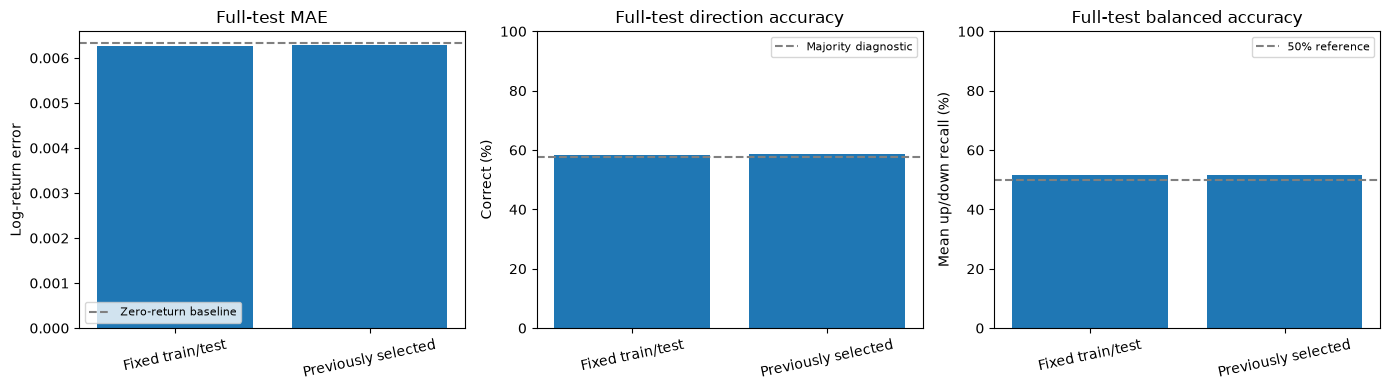

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['Fixed train/test', 'Previously selected']
axes[0].bar(labels, comparison.return_mae)
axes[0].axhline(fixed_metric.zero_return_mae, color='gray', linestyle='--', label='Zero-return baseline')
axes[0].set(title='Full-test MAE', ylabel='Log-return error')
axes[1].bar(labels, 100*comparison.direction_accuracy)
axes[1].axhline(100*fixed_metric.majority_baseline, color='gray', linestyle='--', label='Majority diagnostic')
axes[1].set(title='Full-test direction accuracy', ylabel='Correct (%)', ylim=(0,100))
axes[2].bar(labels, 100*comparison.balanced_accuracy)
axes[2].axhline(50, color='gray', linestyle='--', label='50% reference')
axes[2].set(title='Full-test balanced accuracy', ylabel='Mean up/down recall (%)', ylim=(0,100))
for ax in axes:
    ax.tick_params(axis='x', labelrotation=12)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / 'comparison_metrics.png', dpi=160)
plt.show()

## 5. Forecasts after a chosen date

The panels show the actual return and both return forecasts for identical target dates. Reconstructed prices use the actual issue close multiplied by the exponential of that method's predicted return. The forecast model continues to output log returns only. `PLOT_AFTER_DATE` changes the display slice; full-period metrics above are unchanged.

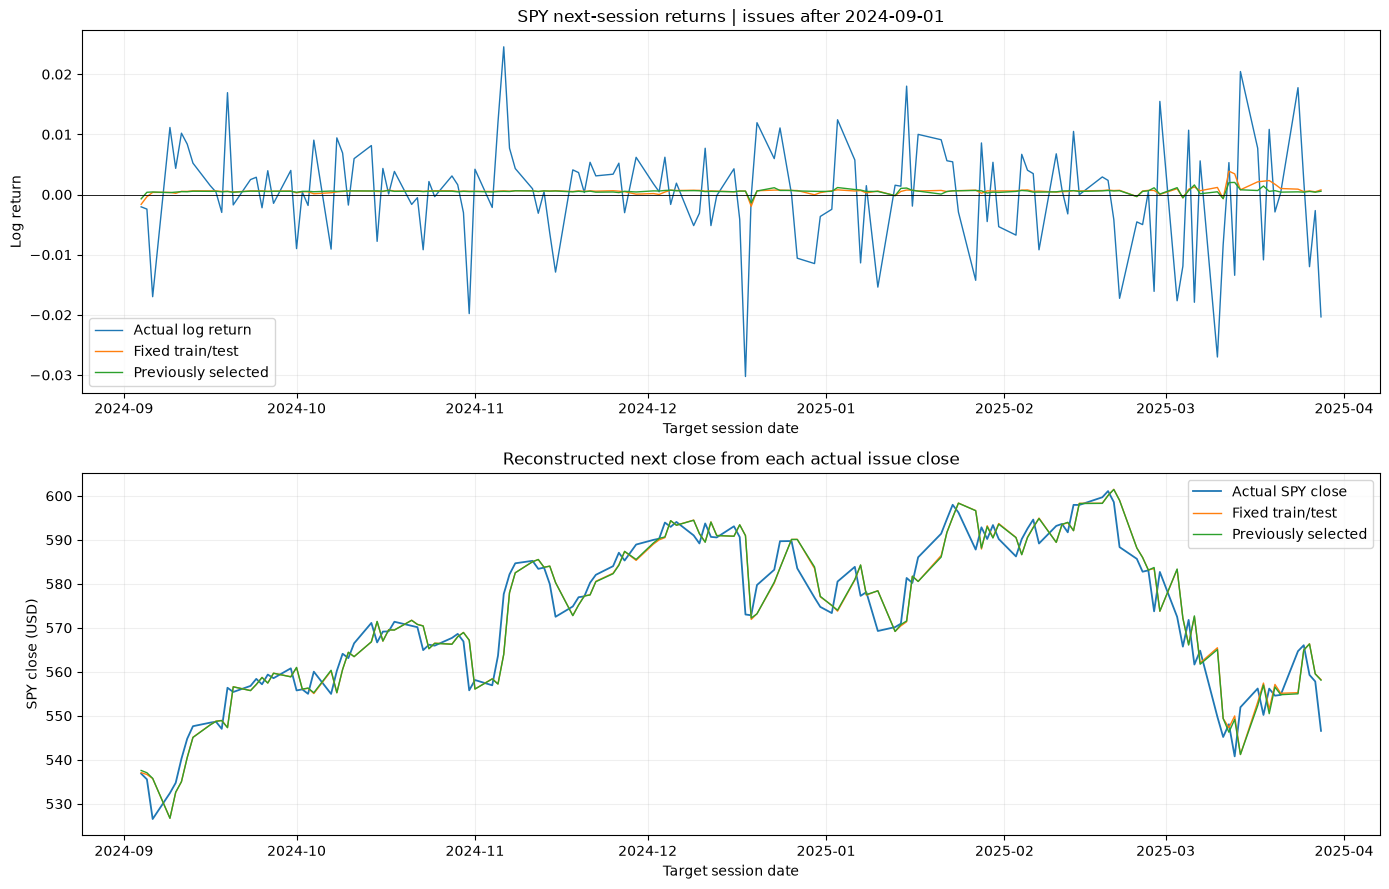

In [6]:
after = pd.Timestamp(PLOT_AFTER_DATE)
shown_fixed = fixed.loc[pd.to_datetime(fixed.issue_date) > after].copy()
shown_reference = reference.loc[pd.to_datetime(reference.issue_date) > after].copy()
if shown_fixed.empty:
    raise ValueError('Choose PLOT_AFTER_DATE before the end of the test issue period.')
dates = pd.to_datetime(shown_fixed.target_date)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].plot(dates, shown_fixed.actual_return, label='Actual log return', linewidth=1)
axes[0].plot(dates, shown_fixed.predicted_return, label='Fixed train/test', linewidth=1)
axes[0].plot(dates, shown_reference.predicted_return, label='Previously selected', linewidth=1)
axes[0].axhline(0, color='black', linewidth=.6)
axes[0].set(title=f'SPY next-session returns | issues after {PLOT_AFTER_DATE}', ylabel='Log return')
fixed_prices = reconstruct_price_comparison(shown_fixed, market)
reference_prices = reconstruct_price_comparison(shown_reference, market)
axes[1].plot(dates, fixed_prices.actual_close, label='Actual SPY close', linewidth=1.3)
axes[1].plot(dates, fixed_prices.predicted_close, label='Fixed train/test', linewidth=1)
axes[1].plot(dates, reference_prices.predicted_close, label='Previously selected', linewidth=1)
axes[1].set(title='Reconstructed next close from each actual issue close', ylabel='SPY close (USD)')
for ax in axes:
    ax.set_xlabel('Target session date')
    ax.legend()
    ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(OUTPUT / 'comparison_returns_and_prices.png', dpi=160)
plt.show()
price_table = fixed_prices.rename(columns={'predicted_close': 'fixed_predicted_close',
                                           'predicted_return': 'fixed_predicted_return'})
price_table['reference_predicted_close'] = reference_prices.predicted_close.to_numpy()
price_table['reference_predicted_return'] = reference_prices.predicted_return.to_numpy()
price_table.to_csv(OUTPUT / 'after_date_price_comparison.csv', index=False)

## 6. Review notes

- No validation search is run in this notebook. The fixed model's settings come from the pre-existing library defaults, while the reference configuration retains its prior selection provenance.
- A different signature depth or penalty can change results; the presence of a validation step is not itself a parameter in the fitting equations.
- The same 2023 observations already enter both test-time rolling training windows after their labels mature. Inspect the training-calendar table rather than assuming more data are added by removing a split.
- Low return correlation and mostly-up forecasts can coexist with accuracy near the majority-direction baseline. Examine magnitude and direction metrics together.
- This previously examined test sample is useful for comparison, but it cannot serve as fresh evidence after repeated parameter changes.

Shared implementation: `src/spy_adaptive_lasso.py`. Outputs: `results/train_test_comparison/`. The original report and its result files are retained.